# Expérience

In [2]:
from vote_simulation.simulation.simulation import simulation_series_from_config

results = simulation_series_from_config("demo.toml", reload=True, compute_metrics=True)

Running simulation series: 100%|██████████| 12/12 [01:29<00:00,  7.48s/it]

Completed 12 simulation series.


## Résultats
### Matrix of metric

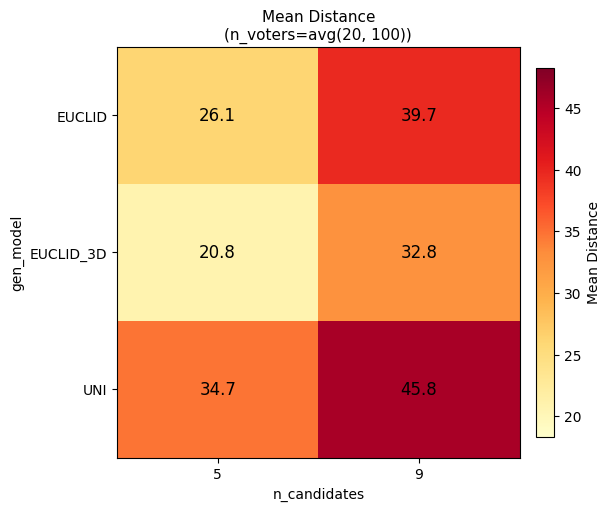

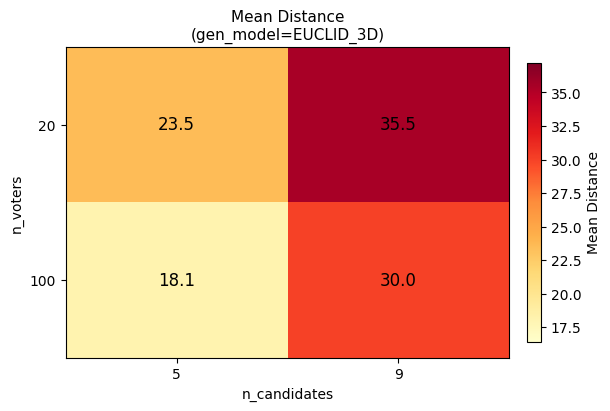

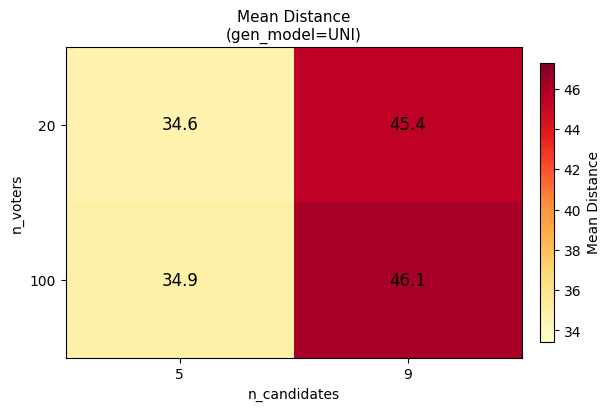

<Axes: title={'center': 'Mean Distance\n(gen_model=UNI)'}, xlabel='n_candidates', ylabel='n_voters'>

In [4]:
results.plot_metric_heatmap(row_param="gen_model", col_param="n_candidates")
results.filter(gen_model="EUCLID_3D").plot_metric_heatmap(row_param="n_voters", col_param="n_candidates")
results.filter(gen_model="UNI").plot_metric_heatmap(row_param="n_voters", col_param="n_candidates")

## Metrics
### Summary 

gen_model  n_voters  n_candidates  step_count  n_iterations  mean_distance most_distant_rule_a most_distant_rule_b  most_distant_distance
   EUCLID        20             5        1000          1000      26.989345                BORD                PLU1              51.180000
   EUCLID        20             9        1000          1000      40.664882                BORD                PLU1              74.419998
   EUCLID       100             5        1000          1000      25.126785                BORD                PLU1              57.549999
   EUCLID       100             9        1000          1000      38.757738                BORD                PLU1              80.016670
EUCLID_3D        20             5        1000          1000      23.489345                BORD                PLU1              44.063332
EUCLID_3D        20             9        1000          1000      35.492440                BORD                PLU1              66.881668
EUCLID_3D       100             5 

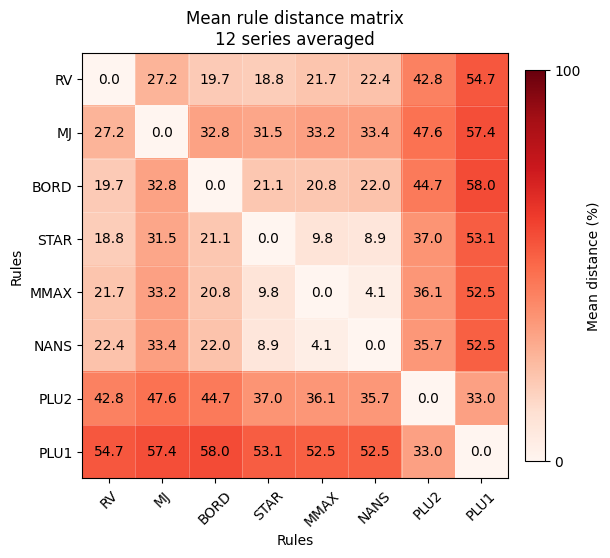

<Axes: title={'center': 'Mean rule distance matrix\n12 series averaged'}, xlabel='Rules', ylabel='Rules'>

In [2]:
df = results.summary_frame()
print(df.to_string(index=False))

results.plot_mean_distance_matrix()

## Rule pair distance
`rule_pair_frame()` extracts the mean distance between two specific rules across all series:



In [5]:
df = results.rule_pair_frame("PLU1", "BORD")
print(df.to_string(index=False))

gen_model  n_voters  n_candidates  distance
   EUCLID        20             5 51.180000
   EUCLID        20             9 74.419998
   EUCLID       100             5 57.549999
   EUCLID       100             9 80.016670
EUCLID_3D        20             5 44.063332
EUCLID_3D        20             9 66.881668
EUCLID_3D       100             5 41.916668
EUCLID_3D       100             9 66.033333
      UNI        20             5 43.691666
      UNI        20             9 60.560001
      UNI       100             5 45.185001
      UNI       100             9 64.754997


## Rule pair heatmap 
Focus single pair 

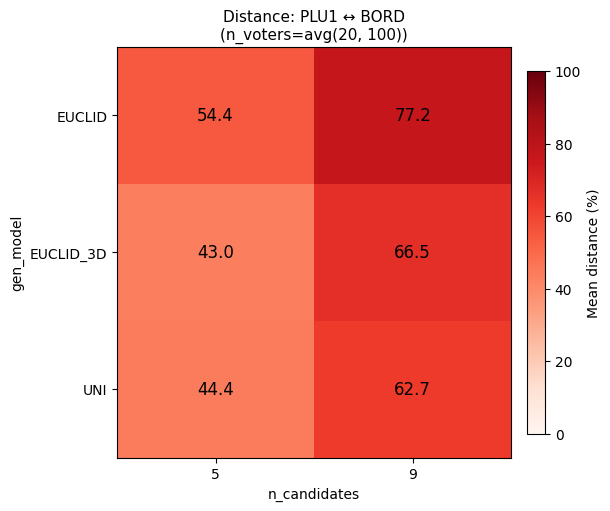

<Axes: title={'center': 'Distance: PLU1 ↔ BORD\n(n_voters=avg(20, 100))'}, xlabel='n_candidates', ylabel='gen_model'>

In [6]:
results.plot_rule_pair_heatmap(
    "PLU1",
    "BORD",
    row_param="gen_model",
    col_param="n_candidates",
    show=True,
)

## Comparison 

    gen_model  n_voters  n_candidates  step_count  n_iterations  \
0      EUCLID        20             5        1000          1000   
1      EUCLID        20             9        1000          1000   
2      EUCLID       100             5        1000          1000   
3      EUCLID       100             9        1000          1000   
4   EUCLID_3D        20             5        1000          1000   
5   EUCLID_3D        20             9        1000          1000   
6   EUCLID_3D       100             5        1000          1000   
7   EUCLID_3D       100             9        1000          1000   
8         UNI        20             5        1000          1000   
9         UNI        20             9        1000          1000   
10        UNI       100             5        1000          1000   
11        UNI       100             9        1000          1000   

    mean_distance most_distant_rule_a most_distant_rule_b  \
0       26.989345                BORD                PLU1   
1     

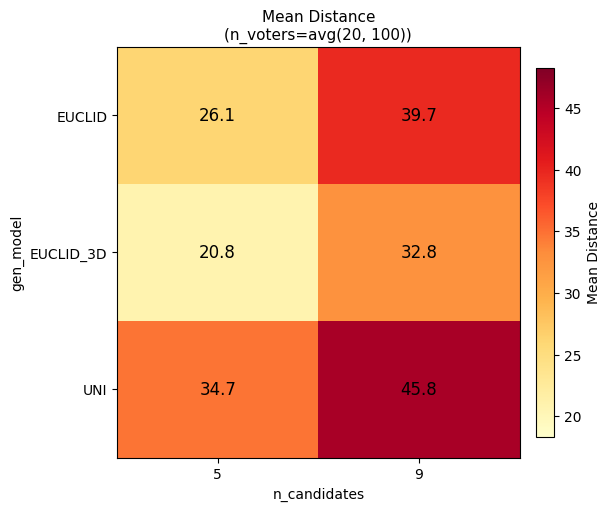

<Axes: title={'center': 'Mean Distance\n(n_voters=avg(20, 100))'}, xlabel='n_candidates', ylabel='gen_model'>

In [7]:
summary = results.summary_frame()
print(summary)

results.plot_metric_heatmap(row_param="gen_model", col_param="n_candidates")

## Elected caracteristics

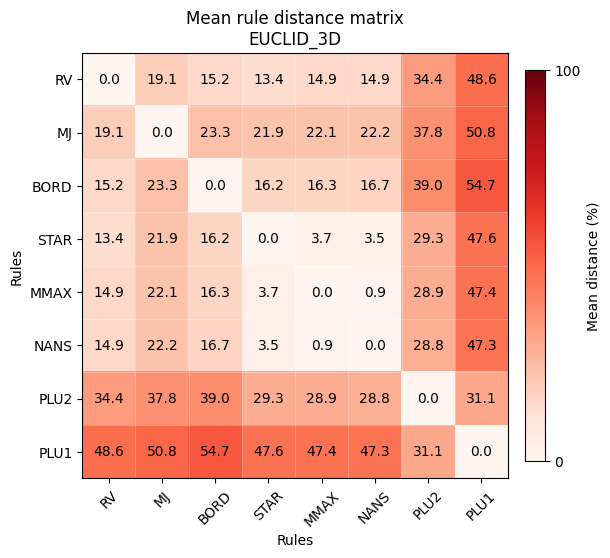

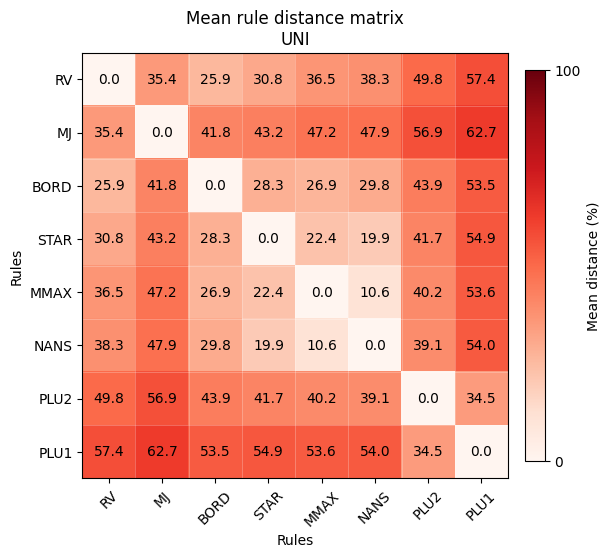

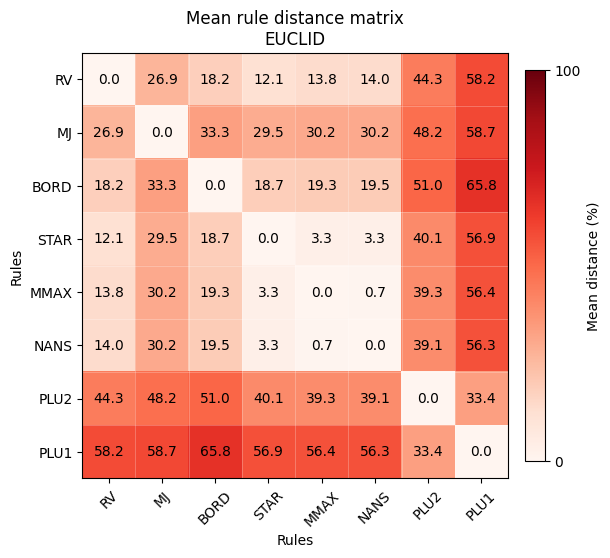

<Axes: title={'center': 'Mean rule distance matrix\nEUCLID'}, xlabel='Rules', ylabel='Rules'>

In [8]:
series = results.filter(gen_model="EUCLID_3D")
series.plot_mean_distance_matrix()

series = results.filter(gen_model="UNI")
series.plot_mean_distance_matrix()

series = results.filter(gen_model="EUCLID")
series.plot_mean_distance_matrix()

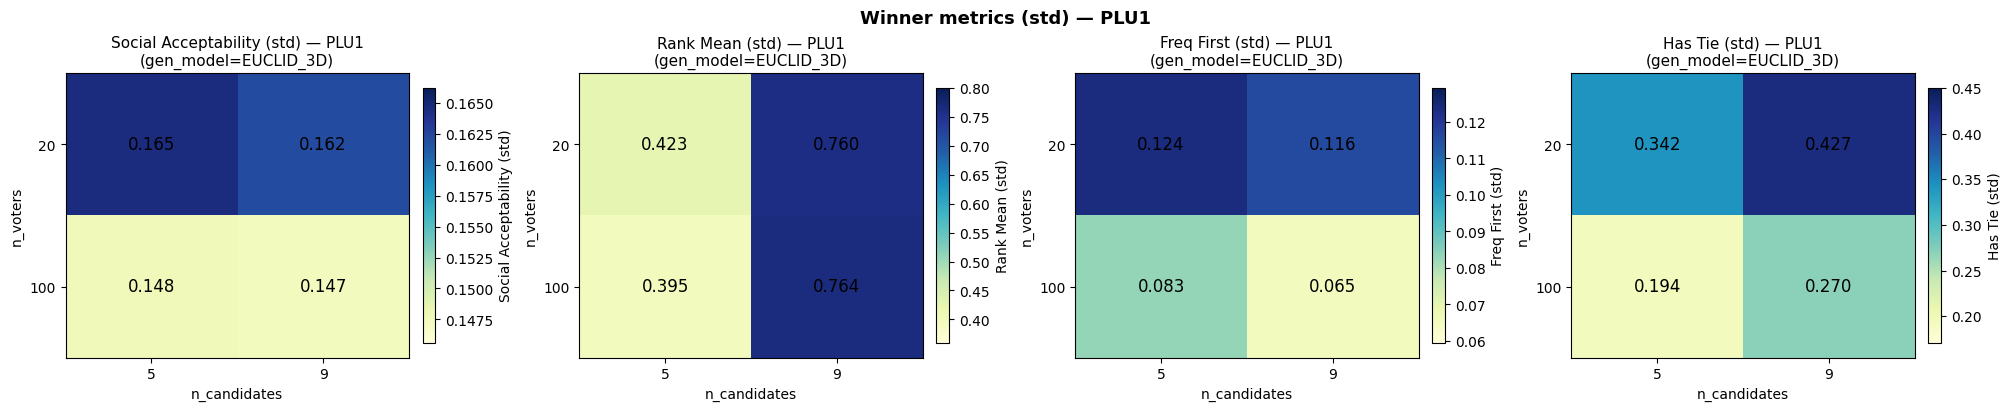

array([<Axes: title={'center': 'Social Acceptability (std) — PLU1\n(gen_model=EUCLID_3D)'}, xlabel='n_candidates', ylabel='n_voters'>,
       <Axes: title={'center': 'Rank Mean (std) — PLU1\n(gen_model=EUCLID_3D)'}, xlabel='n_candidates', ylabel='n_voters'>,
       <Axes: title={'center': 'Freq First (std) — PLU1\n(gen_model=EUCLID_3D)'}, xlabel='n_candidates', ylabel='n_voters'>,
       <Axes: title={'center': 'Has Tie (std) — PLU1\n(gen_model=EUCLID_3D)'}, xlabel='n_candidates', ylabel='n_voters'>],
      dtype=object)

In [8]:
results.filter(gen_model="EUCLID_3D").plot_winner_metrics_grid(
    "PLU1",
    metrics=["social_acceptability", "rank_mean", "freq_first", "has_tie"],
    stat="std",
)

## Metrics matrix

Matrice règles × métriques : chaque ligne est une métrique, chaque colonne une règle.  
Le dégradé est normailsé par métrique pour que les règles soient comparables.  

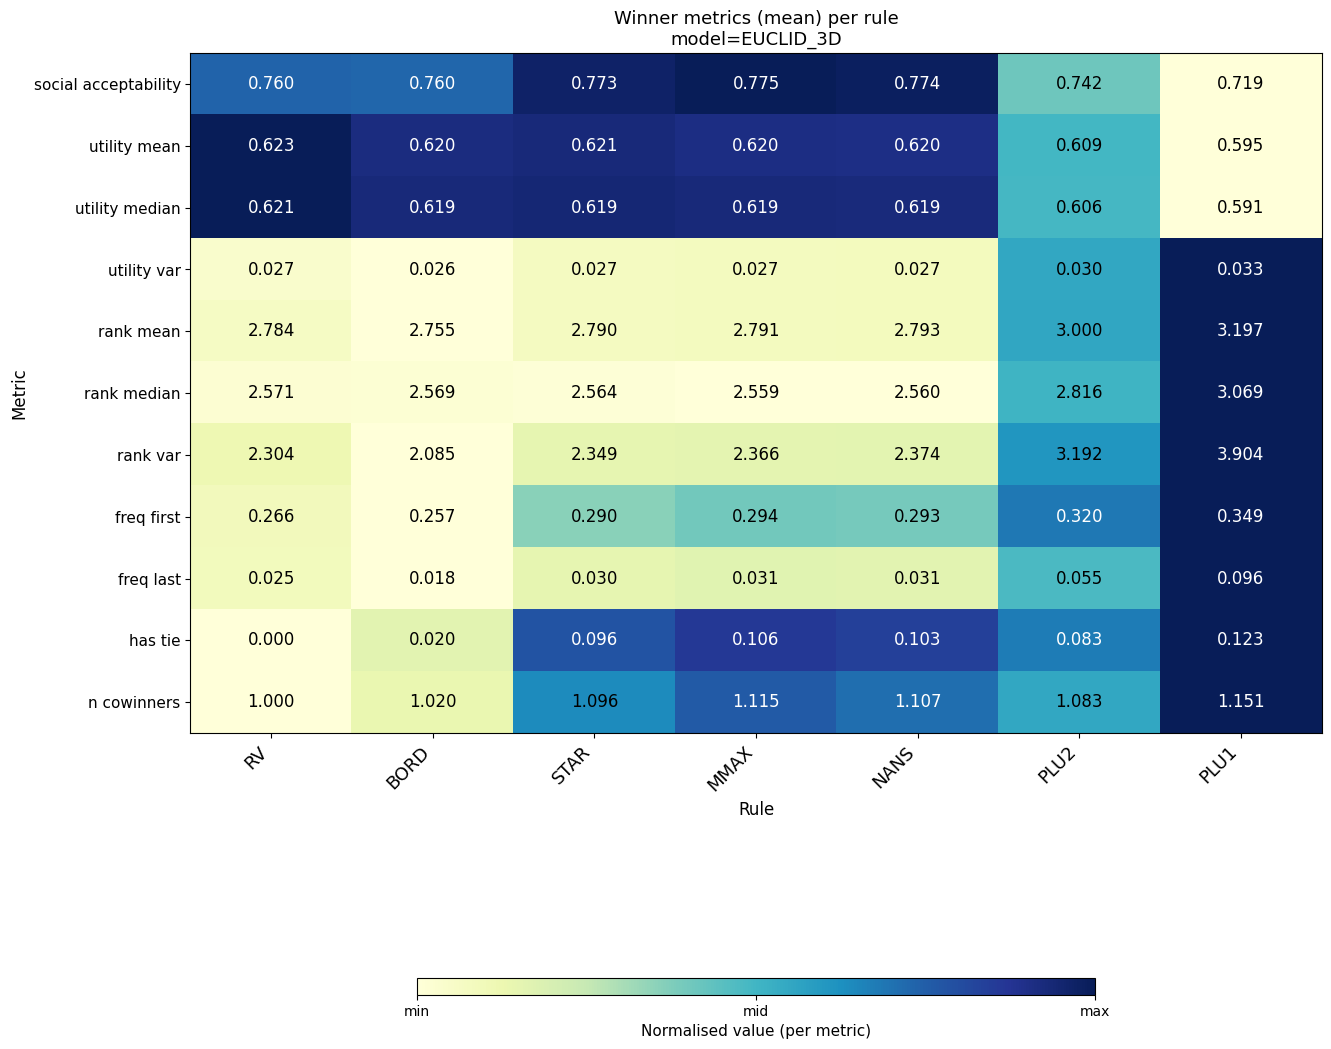

<Axes: title={'center': 'Winner metrics (mean) per rule\nmodel=EUCLID_3D'}, xlabel='Rule', ylabel='Metric'>

In [9]:
results.filter(gen_model="EUCLID_3D").plot_metrics_rules_matrix(
    stat="mean", save_path="results/metrics_rules_matrix.png"
)

In [1]:
#
results.filter(gen_model="UNI").plot_metrics_rules_matrix(
    metrics=["social_acceptability", "rank_mean", "freq_first", "has_tie"],
    stat="mean",
    save_path="results/metrics_rules_matrix_UNI.png",
)

NameError: name 'results' is not defined